# Docs figures

Render figures referenced from `docs/substrat_model.md` without re-running
the full modelling notebook. Numbers below are pulled from the results
tables in that document.


In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm, colors

import mnk.sources

FIG_DIR = Path('../../figures')
FIG_DIR.mkdir(exist_ok=True)

In [2]:
def region_performance_map(
    region_gdf,
    region_stats,
    region_col='Region',
    accuracy_key='accuracy',
    n_key='n_samples',
    cmap_name='RdYlGn',
    vmin=0.5,
    vmax=0.9,
    figsize=(12, 10),
    buffer_m=15000,
    title='Held-out validation accuracy by marine water-type region',
):
    """Choropleth of per-region accuracy with a companion bar chart.

    Regions are buffered outward by ``buffer_m`` metres so narrow coastal slivers
    become visible bands, and labels are placed as callouts to the right of the
    map with leader lines to each region.
    """
    from shapely.ops import polylabel

    gdf = region_gdf.copy()
    gdf['geometry'] = gdf.geometry.buffer(buffer_m)
    gdf['_acc'] = gdf[region_col].map(lambda r: region_stats.get(r, {}).get(accuracy_key))
    gdf['_n'] = gdf[region_col].map(lambda r: region_stats.get(r, {}).get(n_key))

    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = cm.get_cmap(cmap_name)

    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(1, 2, width_ratios=[2, 1], wspace=0.05)
    ax = fig.add_subplot(gs[0, 0])
    ax_bar = fig.add_subplot(gs[0, 1])

    gdf.plot(
        ax=ax,
        color=[cmap(norm(a)) if a is not None and not np.isnan(a) else '#cccccc' for a in gdf['_acc']],
        edgecolor='#111111',
        linewidth=1.2,
        alpha=0.9,
    )

    # Callout labels along the right side of the map so codes never overlap the
    # narrow polygons themselves. Anchor points are the pole-of-inaccessibility.
    for _, row in gdf.iterrows():
        geom = row.geometry
        try:
            biggest = max(geom.geoms, key=lambda g: g.area) if geom.geom_type == 'MultiPolygon' else geom
            p = polylabel(biggest, tolerance=500)
        except Exception:
            p = geom.representative_point()
        ax.annotate(
            str(row[region_col]),
            xy=(p.x, p.y),
            ha='center', va='center',
            fontsize=15, fontweight='bold', color='#111111',
            bbox=dict(boxstyle='circle,pad=0.35', fc='white', ec='#111111', lw=1.2),
            zorder=5,
        )

    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=0.55, pad=0.02)
    cbar.set_label('Accuracy')

    ax.set_title(title, fontsize=12)
    ax.set_aspect('equal')
    ax.set_axis_off()

    bar_order = ['B', 'G', 'H', 'M', 'N', 'S']
    bar_df = gdf[[region_col, '_acc', '_n']].dropna(subset=['_acc']).set_index(region_col)
    bar_df = bar_df.reindex([r for r in bar_order if r in bar_df.index]).iloc[::-1].reset_index()
    y = np.arange(len(bar_df))
    bar_colors = [cmap(norm(a)) for a in bar_df['_acc']]
    ax_bar.barh(y, bar_df['_acc'], color=bar_colors, edgecolor='#333333', linewidth=0.5)
    ax_bar.set_yticks(y)
    ax_bar.set_yticklabels(bar_df[region_col], fontsize=11, fontweight='bold')
    ax_bar.set_xlim(0, 1)
    ax_bar.set_xlabel('Accuracy')
    ax_bar.set_title('Accuracy and validation n', fontsize=11)
    for spine in ('top', 'right'):
        ax_bar.spines[spine].set_visible(False)
    ax_bar.axvline(bar_df['_acc'].mean() if len(bar_df) else 0.0,
                   color='#555555', linestyle='--', linewidth=0.8, alpha=0.6)
    for yi, (acc, nn) in enumerate(zip(bar_df['_acc'], bar_df['_n'])):
        ax_bar.text(acc + 0.01, yi, f"{acc:.2f}  •  n={int(nn):,}",
                    va='center', ha='left', fontsize=9)

    plt.tight_layout()
    return fig, (ax, ax_bar)

In [3]:
# Regional accuracy and validation sample counts pulled from
# docs/substrat_model.md (Results → Regional performance).
REGION_STATS = {
    'B': {'accuracy': 0.807, 'n_samples': 237_623},
    'G': {'accuracy': 0.715, 'n_samples': 360_869},
    'H': {'accuracy': 0.711, 'n_samples': 136_658},
    'M': {'accuracy': 0.735, 'n_samples': 280_829},
    'N': {'accuracy': 0.692, 'n_samples':  83_763},
    'S': {'accuracy': 0.778, 'n_samples':  53_409},
}

In [4]:
mv = mnk.sources.marine_vanntyper().to_crs('EPSG:25833')
region_gdf = mv.dissolve(by='Region', as_index=False)[['Region', 'geometry']]
region_gdf

,Region,geometry
0,B,"MULTIPOLYGON (((737636.56 7764626.25, 737649.3..."
1,G,"MULTIPOLYGON (((438710.11 7426495.22, 438673.0..."
2,H,"MULTIPOLYGON (((44359.87 6913996.94, 44365.91 ..."
3,M,"POLYGON ((-33509.29 6747331.05, -33514.74 6747..."
4,N,"POLYGON ((-46751.78 6607047.11, -46757.6 66070..."
5,S,"POLYGON ((46916.49 6457415.3, 46912.87 6457414..."


<positron-console-cell-5>:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
<positron-console-cell-5>:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


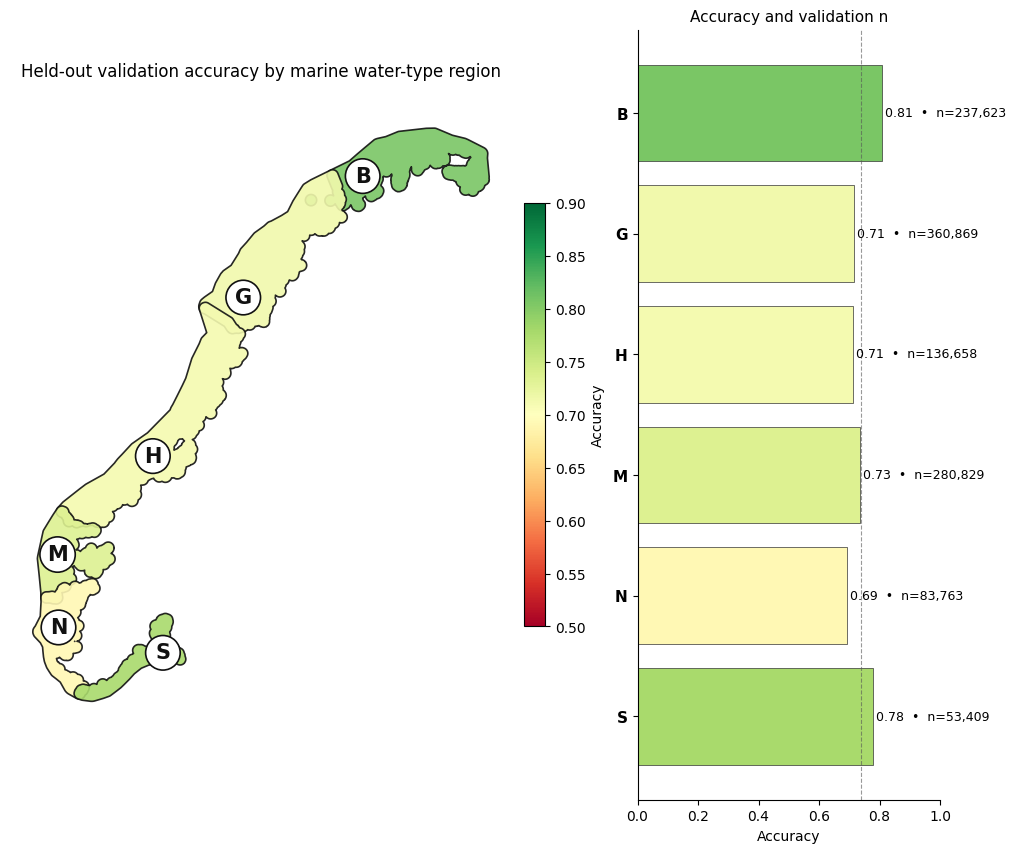

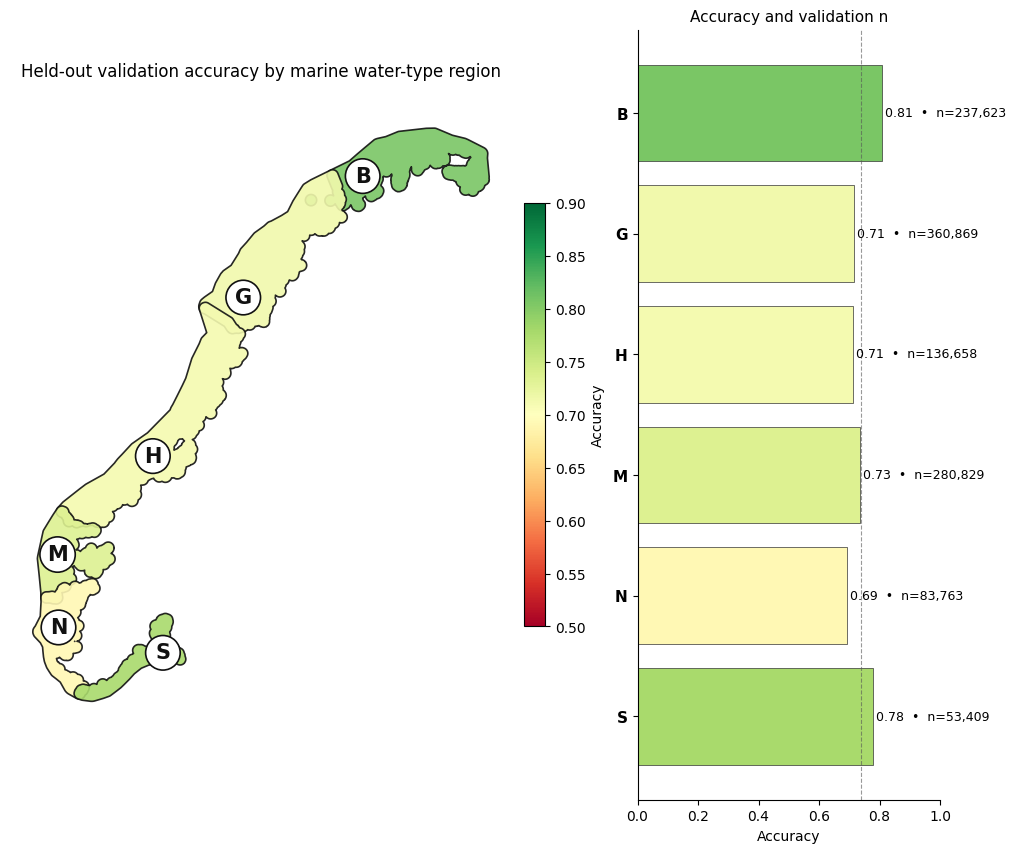

In [5]:
fig, ax = region_performance_map(region_gdf, REGION_STATS, region_col='Region')
fig.savefig(FIG_DIR / 'regional_performance.png', dpi=150, bbox_inches='tight')
fig